# Convolution

In this document we will implement an equivariant convolution with `e3nn`.
We will implement this formula:

$$
f'_i = \frac{1}{\sqrt{z}} \sum_{j \in \partial(i)} \; f_j \; \otimes\!(h(\|x_{ij}\|)) \; Y(x_{ij} / \|x_{ij}\|)
$$

where

- $f_j, f'_i$ are the nodes input and output
- $z$ is the average `degree`_ of the nodes
- $\partial(i)$ is the set of neighbors of the node $i$
- $x_{ij}$ is the relative vector
- $h$ is a multi layer perceptron
- $Y$ is the spherical harmonics
- $x \; \otimes\!(w) \; y$ is a tensor product of $x$ with $y$ parametrized by some weights $w$

Boilerplate imports

In [37]:
import torch
from torch_cluster import radius_graph
from torch_scatter import scatter
from e3nn import o3, nn
from e3nn.math import soft_one_hot_linspace
import matplotlib.pyplot as plt

Let's first define the irreps of the input and output features.

In [38]:
irreps_input = o3.Irreps("10x0e + 10x1e")
irreps_output = o3.Irreps("20x0e + 10x1e")

And create a random graph using random positions and edges when the relative distance is smaller than `max_radius`.

In [39]:
from figure_dataset import generate_dataset

X, y = generate_dataset(100,100)

pos = torch.tensor(X[0], dtype=torch.float32)
len(pos[0])

# create edges
max_radius = 0.7
edge_src, edge_dst = radius_graph(pos, max_radius, max_num_neighbors=num_nodes - 1)

print(edge_src.shape)

edge_vec = pos[edge_dst] - pos[edge_src]

# compute z
num_neighbors = len(edge_src) / num_nodes
num_neighbors

X

torch.Size([2972])


array([[[ 0.32596725,  0.47409799, -0.13634086],
        [-0.04778362, -0.32996365, -0.41155329],
        [ 0.43942207, -0.18022565,  0.58559458],
        ...,
        [ 0.1858811 , -0.48294802,  0.3144037 ],
        [ 0.53494809,  0.33392833, -0.20103456],
        [-0.60903842, -0.03343899, -0.12423969]],

       [[-0.4593218 , -0.37204333, -0.01481986],
        [ 0.13929644,  0.15889353, -0.48567967],
        [-0.35029334,  0.47295846,  0.47127373],
        ...,
        [-0.02100257,  0.58801771,  0.14294872],
        [-0.61592607, -0.20215571, -0.13364366],
        [ 0.58688557, -0.19060639, -0.08195118]],

       [[ 0.0726825 , -0.13961306, -0.56994546],
        [-0.47754812, -0.14442743,  0.17783111],
        [ 0.61699967, -0.37897404,  0.21020026],
        ...,
        [ 0.2240322 , -0.30360939,  0.47357278],
        [ 0.03208392, -0.39332511, -0.53137413],
        [-0.28188955,  0.52428993,  0.18204345]],

       ...,

       [[ 0.23434797, -0.65768167, -0.09142158],
        [-0

`edge_src` and `edge_dst` contain the indices of the nodes for each edge.
And we can also create some random input features.

In [40]:
f_in = irreps_input.randn(num_nodes, -1)

Note that out data is generated with a normal distribution. We will take care of having all the data following the `component` normalization (see *norm guide*).

In [41]:
f_in.pow(2).mean()  # should be close to 1

tensor(1.0053)

In [42]:
f_in

tensor([[-1.9553,  0.2610, -0.1571,  ..., -0.8872, -0.7182, -0.2275],
        [-0.9365, -1.4478,  0.8599,  ...,  0.6495, -1.6466,  0.8158],
        [-1.3394,  0.9598, -0.4457,  ..., -2.0695, -1.0111, -0.4262],
        ...,
        [ 0.2127,  2.7781, -0.6504,  ...,  0.6314,  0.2283,  1.2349],
        [ 1.0242,  1.9845,  2.0852,  ...,  2.1802,  1.0479,  0.4355],
        [-0.4117,  0.4484, -0.0289,  ..., -1.8560,  0.8765, -0.6642]])

In [43]:
f_in.size()

torch.Size([100, 40])

Let's start with

$$
Y(x_{ij} / \|x_{ij}\|)
$$

In [44]:
irreps_sh = o3.Irreps.spherical_harmonics(lmax=2)
print(irreps_sh)

sh = o3.spherical_harmonics(irreps_sh, edge_vec, normalize=True, normalization='component')
# normalize=True ensure that x is divided by |x| before computing the sh

sh.pow(2).mean()  # should be close to 1

1x0e+1x1o+1x2e


tensor(1.)

Now we need to compute $\otimes(w)$ and $h$.
Let's create the tensor product first, it will tell us how many weights it needs.

FullyConnectedTensorProduct(10x0e+10x1e x 1x0e+1x1o+1x2e -> 20x0e+10x1e | 400 paths | 400 weights) needs 400 weights


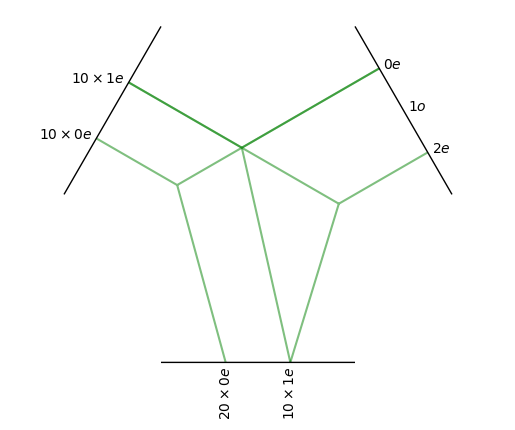

In [45]:
tp = o3.FullyConnectedTensorProduct(irreps_input, irreps_sh, irreps_output, shared_weights=False)

print(f"{tp} needs {tp.weight_numel} weights")

tp.visualize();

in this particual choice of irreps we can see that the l=1 component of the spherical harmonics cannot be used in the tensor product.
In this example it's the equivariance to inversion that prohibit the use of l=1.
If we don't want the equivariance to inversion we can declare all irreps to be even (`irreps_sh = Irreps("0e + 1e + 2e")`).

To implement $h$ that has to map the relative distances to the weights of the tensor product we will embed the distances using a basis function and then feed this embedding to a neural network.
Let's create that embedding. Here is the base functions we will use:

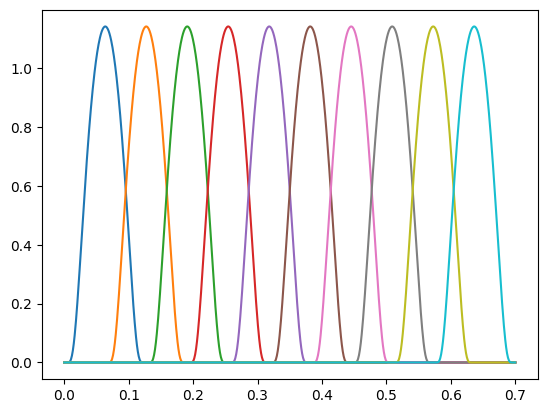

In [46]:
num_basis = 10

x = torch.linspace(0.0, 0.7, 1000)
y = soft_one_hot_linspace(
    x,
    start=0.0,
    end=max_radius,
    number=num_basis,
    basis='smooth_finite',
    cutoff=True,
)

plt.plot(x, y);

Note that this set of functions are all smooth and are strictly zero beyond `max_radius`.
This is useful to get a convolution that is smooth although the sharp cutoff at `max_radius`.

Let's use this embedding for the edge distances and normalize it properly (`component` i.e. second moment close to 1).

In [47]:
edge_length_embedding = soft_one_hot_linspace(
    edge_vec.norm(dim=1),
    start=0.0,
    end=max_radius,
    number=num_basis,
    basis='smooth_finite',
    cutoff=True,
)
edge_length_embedding = edge_length_embedding.mul(num_basis**0.5)

print(edge_length_embedding.shape)
edge_length_embedding.pow(2).mean()  # the second moment

torch.Size([2972, 10])


tensor(0.8962)

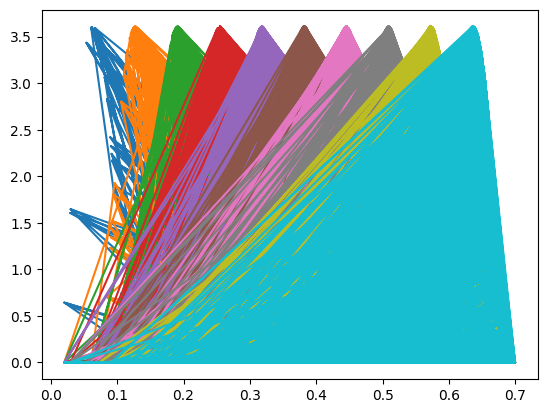

In [48]:
plt.plot(edge_vec.norm(dim=1), edge_length_embedding)

Now we can create a MLP and feed it

In [49]:
fc = nn.FullyConnectedNet([num_basis, 16, tp.weight_numel], torch.relu)
weight = fc(edge_length_embedding)

print(weight.shape)
print(len(edge_src), tp.weight_numel)

# For a proper notmalization, the weights also need to be mean 0
print(weight.mean(), weight.std())  # should close to 0 and 1

torch.Size([2972, 400])
2972 400
tensor(0.0284, grad_fn=<MeanBackward0>) tensor(0.8210, grad_fn=<StdBackward0>)


Now we can compute the term

$$
f_j \; \otimes\!(h(\|x_{ij}\|)) \; Y(x_{ij} / \|x_{ij}\|)
$$

The idea is to compute this quantity per edges, so we will need to "lift" the input feature to the edges.
For that we use `edge_src` that contains, for each edge, the index of the source node.

In [50]:
summand = tp(f_in[edge_src], sh, weight)

print(summand.shape)
print(summand.pow(2).mean())  # should be close to 1

torch.Size([2972, 50])
tensor(0.7080, grad_fn=<MeanBackward0>)


Only the sum over the neighbors is remaining

$$
f'_i = \frac{1}{\sqrt{z}} \sum_{j \in \partial(i)} \; f_j \; \otimes\!(h(\|x_{ij}\|)) \; Y(x_{ij} / \|x_{ij}\|)
$$

In [51]:
f_out = scatter(summand, edge_dst, dim=0, dim_size=num_nodes)

f_out = f_out.div(num_neighbors**0.5)

# f_out.pow(2).mean()  # should be close to 1
f_out

tensor([[-0.2659,  0.2291,  0.4206,  ...,  1.4045, -0.3269, -0.0858],
        [-2.1263,  0.6332,  0.1640,  ...,  1.5208,  0.4657, -0.5134],
        [-0.5848,  0.8490, -0.9533,  ...,  0.2481,  0.5981,  0.5611],
        ...,
        [-1.3386, -0.0783, -0.3611,  ...,  0.9309,  0.5252, -0.6890],
        [ 0.4546,  1.0435, -0.1428,  ..., -0.5428, -0.6916,  0.5305],
        [-3.2163, -1.1040,  0.7718,  ..., -0.6394, -1.3384,  0.0403]],
       grad_fn=<DivBackward0>)

In [52]:
f_out.size()

torch.Size([100, 50])

Now we can put everything into a function

In [53]:
def conv(f_in, pos):
    edge_src, edge_dst = radius_graph(pos, max_radius, max_num_neighbors=len(pos) - 1)
    edge_vec = pos[edge_dst] - pos[edge_src]
    sh = o3.spherical_harmonics(irreps_sh, edge_vec, normalize=True, normalization='component')
    emb = soft_one_hot_linspace(edge_vec.norm(dim=1), 0.0, max_radius, num_basis, basis='smooth_finite', cutoff=True).mul(num_basis**0.5)
    return scatter(tp(f_in[edge_src], sh, fc(emb)), edge_dst, dim=0, dim_size=num_nodes).div(num_neighbors**0.5)

Now we can check the equivariance

In [54]:
rot = o3.rand_matrix()
D_in = irreps_input.D_from_matrix(rot)
D_out = irreps_output.D_from_matrix(rot)

# rotate before
f_before = conv(f_in @ D_in.T, pos @ rot.T)

# rotate after
f_after = conv(f_in, pos) @ D_out.T

torch.allclose(f_before, f_after, rtol=1e-4, atol=1e-4)

True

The tensor product dominates the execution time:

In [55]:
import time
wall = time.perf_counter()

edge_src, edge_dst = radius_graph(pos, max_radius, max_num_neighbors=len(pos) - 1)
edge_vec = pos[edge_dst] - pos[edge_src]
print(time.perf_counter() - wall); wall = time.perf_counter()

sh = o3.spherical_harmonics(irreps_sh, edge_vec, normalize=True, normalization='component')
print(time.perf_counter() - wall); wall = time.perf_counter()

emb = soft_one_hot_linspace(edge_vec.norm(dim=1), 0.0, max_radius, num_basis, basis='smooth_finite', cutoff=True).mul(num_basis**0.5)
print(time.perf_counter() - wall); wall = time.perf_counter()

weight = fc(emb)
print(time.perf_counter() - wall); wall = time.perf_counter()

summand = tp(f_in[edge_src], sh, weight)
print(time.perf_counter() - wall); wall = time.perf_counter()

scatter(summand, edge_dst, dim=0, dim_size=num_nodes).div(num_neighbors**0.5)
print(time.perf_counter() - wall); wall = time.perf_counter()

0.001233499962836504
0.002032799879088998
0.002782600000500679
0.0011858001817017794
0.007056700065732002
0.0008302000351250172
